In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
df = pd.read_csv('pf_suvs_i302_1s2024.csv')

# Visualizar las primeras filas del dataset para verificar
print(df.head())

     Marca Modelo     Año              Versión   Color Tipo de combustible  \
0  Peugeot   2008  2022.0  1.6 Feline Tip am20  Blanco               Nafta   
1  Peugeot   2008  2021.0           1.6 Allure  Marrón               Nafta   
2  Peugeot   2008  2021.0           1.6 Allure  Marrón               Nafta   
3  Peugeot   2008  2018.0           1.6 Feline  Blanco               Nafta   
4  Peugeot   2008  2016.0        1.6 Thp Sport    Gris               Nafta   

   Puertas Transmisión Motor Tipo de carrocería Kilómetros  \
0      5.0  Automática   1.6                SUV   23000 km   
1      5.0      Manual   1.6                SUV   17000 km   
2      5.0      Manual   1.6                SUV   17500 km   
3      5.0      Manual   1.6                SUV  123600 km   
4      5.0      Manual   1.6                SUV   43000 km   

                             Título      Precio Moneda Tipo de vendedor  \
0  Peugeot 2008 1.6 Feline Tip am20  22499999.0      $           tienda   
1       

In [86]:

def delete_noise_doors(features):
    features = features[features["Puertas"] <= 6]
    return features

def delete_noise_years(features):
    return features[features["Puertas"] <= 2024]

def correct_marca(features):
    if "DS7" in features["Marca"].values:
        features.loc[features["Marca"] == "DS7", "Marca"] = "DS"

    if "DS AUTOMOBILES" in features["Marca"].values:
        features.loc[features["Marca"] == "DS AUTOMOBILES", "Marca"] = "DS"

    if "DS7" in features["Modelo"].values:
        features.loc[features["Modelo"] == "DS7", "Modelo"] = "7"

    if "Jetur" in features["Marca"].values:
        features.loc[features["Marca"] == "Jetur", "Marca"] = "Jetour"

    if "hiunday" in features["Marca"].values:
        features.loc[features["Marca"] == "hiunday", "Marca"] = "Hyundai"

    if "Jetur X70 1.5 Lt At" in features["Título"].values:
        features.loc[features['Título'] == 'Jetur X70 1.5 Lt At', 'Título'] = 'Jetour X70 1.5 Lt At'

    return features

def delete_duplicate(features):
    return features.drop_duplicates().reset_index(drop=True)

def correct_dataset(features):
    features = delete_noise_doors(features)
    features = delete_noise_years(features)
    features = correct_marca(features)
    features = delete_duplicate(features)
    return features

df = correct_dataset(df)


In [87]:
def transform_features_color_2(features):
    list_color = {"gris": ["gris", "gray"], "blanco": ["blanco", "blanca"], "negro": ["negro", "negra", "black"],
                  "plateado": ["plateado", "plata"], "azul": ["azul", "blue"], "rojo": ["rojo", "red"],
                  "marrón": ["marrón", "café"], "dorado": ["dorado"], "verde": ["verde"], "celeste": ["celeste"],
                  "naranja": ["naranja", "orange"], "amarillo": ["amarillo"], "violeta": ["violeta"],
                  "bordó": ["bordó"]}

    for index, value in features["Color"].items():
        if isinstance(value, str):
            word = value.lower()
            cond = False
            for key, sub_list_color in list_color.items():
                for color in sub_list_color:
                    if color in word:
                        features.loc[index, "Color"] = key
                        cond = True
                        break
                if cond:
                    break
            if cond == False:
                features.loc[index, "Color"] = "otro"
        else:
            features.loc[index, "Color"] = "otro"
                        
    return features

In [88]:
def trasform_years_used(features, a):
    if a == True:
        features["Años de uso"] = features["Año"].apply(lambda x: 2024 - x)
        features.drop(["Año"], axis=1, inplace=True)
        features = features[features["Años de uso"] >= 0]
        return features
    else: return features

In [89]:
df = trasform_years_used(df,True)
precio_promedio_por_marca = df.groupby('Años de uso')['Precio'].mean().reset_index()
print(precio_promedio_por_marca)
# Ordenar las marcas por precio promedio de manera descendente
marcas_ordenadas = precio_promedio_por_marca.sort_values(by='Precio', ascending=False)['Años de uso'].tolist()
print(marcas_ordenadas)

    Años de uso        Precio
0           0.0  2.534639e+07
1           1.0  2.311993e+07
2           2.0  1.461610e+07
3           3.0  1.243768e+07
4           4.0  9.154968e+06
5           5.0  9.382969e+06
6           6.0  8.253050e+06
7           7.0  7.536738e+06
8           8.0  7.026844e+06
9           9.0  6.518373e+06
10         10.0  5.958796e+06
11         11.0  4.863645e+06
12         12.0  3.982197e+06
13         13.0  3.175199e+06
14         14.0  2.995988e+06
15         15.0  3.068935e+06
16         16.0  3.354960e+06
17         17.0  3.556600e+06
18         18.0  2.197324e+06
19         19.0  2.483088e+06
20         20.0  3.092334e+06
21         21.0  2.518717e+06
22         22.0  1.218677e+06
23         23.0  2.195779e+06
24         24.0  2.341405e+06
25         25.0  1.005347e+06
26         26.0  1.136605e+06
27         27.0  1.316661e+06
28         28.0  1.869996e+06
29         29.0  1.333442e+06
30         30.0  1.526568e+06
31         31.0  2.035298e+06
32        

In [94]:
# for index, value in df["Modelo"].items():
#         name_marca = df.loc[index, "Marca"]
#         df.loc[index, "Marca"] = f"{name_marca}_{value}_"
precio_promedio_por_marca = df.groupby('Marca')['Precio'].mean().reset_index()
# Ordenar las marcas por precio promedio de manera descendente
marcas_ordenadas = precio_promedio_por_marca.sort_values(by='Precio', ascending=False)['Marca'].tolist()

print(marcas_ordenadas)
print(len(marcas_ordenadas))

['Jeep_Cherokee_Limited_Cherokee_Jeep Grand Cherokee Limited 4x4 2024 0km Atx6_Cherokee_Jeep Grand Cherokee Limited 4x4 2024 0km Atx6', 'Jeep_Cherokee_Limited_Cherokee_Jeep Grand Cherokee Limited 4x4 2024 0km_Cherokee_Jeep Grand Cherokee Limited 4x4 2024 0km', 'Jeep_Cherokee_Limited_Cherokee_Grand Ckerokee Limited.ct_Cherokee_Grand Ckerokee Limited.ct', 'Ford_Mustang_MACH - E AT AWD ELECTRICO_Mustang_Nuevo Ford Mustang Mach - E At Eawd Electrico En Stock #dc_Mustang_Nuevo Ford Mustang Mach - E At Eawd Electrico En Stock #dc', 'Ford_Mustang_Mach-E_Mustang_Ford Mustang Mach-e 2023_Mustang_Ford Mustang Mach-e 2023', 'Ford_Mustang_Mach-E  100% Eléctrico 487cv_Mustang_Ford Mustang Mach E 100% Eléctrico 487cv 0km 2023 Hd_Mustang_Ford Mustang Mach E 100% Eléctrico 487cv 0km 2023 Hd', 'Toyota_SW4_4x4 Diamond II 2.8 TDI 6 at 7as_SW4_Toyota SW4 4x4 Diamond II 2.8 TDI 6 at 7as_SW4_Toyota SW4 4x4 Diamond II 2.8 TDI 6 at 7as', 'DS_7_Rivoli_7_DS 7 Rivoli_7_DS 7 Rivoli', 'Nissan_X-Trail_E-POWER_X-Tra

In [91]:
def func_model(features):
    for index, value in features["Modelo"].items():
        name_marca = features.loc[index, "Marca"]
        name_version = features.loc[index, "Version"]
        name_titulo = features.loc[index, "Título"]
        features.loc[index, "Marca"] = f"{name_marca}_{value}_{name_version}_{name_titulo}"
    print(features["Marca"])
    precio_promedio_por_marca = df.groupby('Marca')['Precio'].mean().reset_index()
    print(precio_promedio_por_marca)
# Ordenar las marcas por precio promedio de manera descendente
    marcas_ordenadas = precio_promedio_por_marca.sort_values(by='Precio', ascending=False)['Marca'].tolist()
    print(marcas_ordenadas)

    list_max_to_min_price = ['Ford_Mustang', 'DS_7', 'DS_DS3', 'Chery_Tiggo 8 Pro', 'Abarth_Pulse', 'Peugeot_5008', 'Jeep_Commander', 'Jetour_X70', 'Citroën_C5 Aircross', 'Ford_Bronco', 'Chevrolet_Equinox', 'Haval_Jolion', 'Volkswagen_Taos', 'Peugeot_3008', 'Nissan_X-Trail', 'Chevrolet_Trailblazer', 'Renault_Kangoo', 'Ford_Bronco Sport', 'Haval_H6', 'Renault_Oroch', 'Volkswagen_Tiguan Allspace', 'Citroën_C3 Aircross', 'Chery_Tiggo 4 Pro', 'Ford_Territory', 'Nissan_Kicks', 'Citroën_Aircross', 'Jeep_Compass', 'Volkswagen_Nivus', 'Renault_Sandero', 'Citroën_C3', 'Peugeot_208', 'Volkswagen_T-Cross', 'Toyota_Corolla Cross', 'Chevrolet_Tracker', 'Fiat_Pulse', 'Citroën_C4 Cactus', 'Jeep_Renegade', 'DS_DS7 Crossback', 'BAIC_X35', 'Chevrolet_Spin', 'Renault_Koleos', 'Renault_Captur', 'Citroën_C4', 'Volkswagen_Suran', 'Toyota_SW4', 'Renault_Duster Oroch', 'Haval_H1', 'JAC_S5', 'Chevrolet_Grand Blazer', 'Renault_Duster', 'Ford_Kuga', 'Lifan_X70', 'Renault_Sandero Stepway', 'Chery_Tiggo 4', 'Peugeot_2008', 'Nissan_Murano', 'Chery_Tiggo 5', 'Geely_Emgrand X7 Sport', 'Chery_Tiggo 2', 'BAIC_X55', 'Volkswagen_Ecosport', 'Ford_Ecosport', 'Honda_HR-V', 'Chevrolet_Agile', 'Toyota_Hilux SW4', 'Chevrolet_Captiva', 'Fiat_500X', 'Kia_Sportage', 'Citroën_C4 Aircross', 'Volkswagen_Tiguan', 'Chery_Tiggo 3', 'Hyundai_Tucson', 'Lexus_NX', 'Chery_Tiggo', 'Jeep_Cherokee', 'Peugeot_4008', 'Toyota_RAV4', 'Hyundai_Santa Fe', 'Hyundai_Kona', 'Kia_Seltos', 'Kia_Sorento', 'Hyundai_Creta', 'Kia_Mohave', 'Kia_Soul', 'Volkswagen_Crossfox', 'Chevrolet_Grand Vitara', 'Dodge_Journey', 'Jeep_Grand Cherokee', 'BAIC_X25', 'BMW_X2', 'Hyundai_Veracruz', 'Ssangyong_Actyon', 'Honda_CR-V', 'Land Rover_Freelander', 'Nissan_X-Terra', 'Isuzu_Trooper', 'Jeep_Patriot', 'Daihatsu_Feroza', 'Lifan_Myway', 'Audi_Q2', 'Chevrolet_Blazer', 'Jeep_Wrangler', 'Mercedes-Benz_Clase GLK', 'BMW_X1', 'Volvo_XC40', 'Audi_Q7', 'Nissan_Pathfinder', 'Nissan_Terrano II', 'Suzuki_Grand Vitara', 'Toyota_4Runner', 'Suzuki_Vitara', 'Volvo_XC60', 'Audi_Q3', 'Land Rover_Discovery', 'Mercedes-Benz_Clase GLB', 'Mercedes-Benz_ML', 'Ssangyong_Musso', 'Audi_Q5', 'Toyota_Land Cruiser', 'Subaru_Outback', 'Volkswagen_Touareg', 'Mitsubishi_Montero', 'BMW_X5', 'Mitsubishi_Outlander', 'Ford_Explorer', 'BMW_X4', 'Isuzu_Rodeo', 'Mercedes-Benz_Clase GLC', 'Land Rover_Evoque', 'Mercedes-Benz_Clase GLA', 'Subaru_Forester', 'BMW_X6', 'Porsche_Cayenne', 'Hyundai_Galloper', 'Daihatsu_Terios', 'BMW_X3', 'Sandero_Sandero', 'Mercedes-Benz_Clase E', 'Audi_E-tron', 'Audi_Q8', 'Lexus_LX', 'Porsche_Macan', 'Porsche_Panamera', 'Mercedes-Benz_Clase GLE', 'Audi_q5 sportback', 'MINI_Countryman', 'Alfa Romeo_Stelvio', 'Audi_SQ5', 'Land Rover_Defender', 'Jaguar_F-PACE', 'Mercedes-Benz_Coupe', 'Audi_Q3 Sportback', 'Mercedes-Benz_Clase GL', 'BMW_Serie 4', 'Toyota_C-HR', 'MINI_Cooper Countryman', 'Lexus_UX', 'Land Rover_Range Rover Sport', 'Hyundai_Grand Santa Fé', 'Mercedes-Benz_Clase ML', 'Land Rover_Range Rover', 'Toyota_Hilux', 'Honda_Pilot', 'JAC_S2', 'Suzuki_Jimny', 'Isuzu_Amigo', 'Suzuki_Samurai', 'Mitsubishi_Nativa']
    
    size_list = len(list_max_to_min_price) 
    order_list = {cat: (size_list - i) / size_list
                  for i, cat in enumerate(list_max_to_min_price)}
    
    def map_feature_to_valor(cat):
        return order_list.get(cat, 0)
    
    print(features["Marca"].values)
    features['Marca'] = features['Marca'].map(map_feature_to_valor)
    print(features["Marca"].values)

In [92]:
func_model(df)

KeyError: 'Version'

In [ ]:
list_max_to_min_price = ['DS', 'Abarth', 'Jetour', 'Haval', 'Volkswagen', 'Citroën', 'Chevrolet', 
                         'Nissan', 'Peugeot', 'Fiat', 'Jeep', 'Renault', 'Toyota', 'Ford', 'BAIC', 
                         'Chery', 'Geely', 'Kia', 'JAC', 'Hyundai', 'Honda', 'Lifan', 'Dodge', 'Lexus', 
                         'Isuzu', 'Volvo', 'Ssangyong', 'Suzuki', 'Audi', 'BMW', 'Daihatsu', 'Mitsubishi', 
                         'Land Rover', 'Mercedes-Benz', 'Subaru', 'Porsche', 'Sandero', 'Alfa Romeo', 
                         'Jaguar', 'MINI']



print(df["Marca"].values)
marca_to_valor = {marca: (len(list_max_to_min_price) - i) / len(list_max_to_min_price) 
                  for i, marca in enumerate(list_max_to_min_price)}

def map_marca_to_valor(marca):
    return marca_to_valor.get(marca, 0)  # Si la marca no está en la lista, se asigna 0

# Aplicar la función al DataFrame y crear una nueva columna
df['Marca'] = df['Marca'].map(map_marca_to_valor)

print(df["Marca"].values)


[0.67857143 0.67857143 0.67857143 ... 0.33928571 0.33928571 0.33928571]
[0 0 0 ... 0 0 0]


In [ ]:
# Scatter plot para Año vs Precio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Año', y='Precio', data=df)
plt.title('Relación entre Año y Precio')
plt.show()

# Scatter plot para Kilómetros vs Precio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Kilómetros', y='Precio', data=df)
plt.title('Relación entre Kilómetros y Precio')
plt.show()


ValueError: Could not interpret value `Año` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

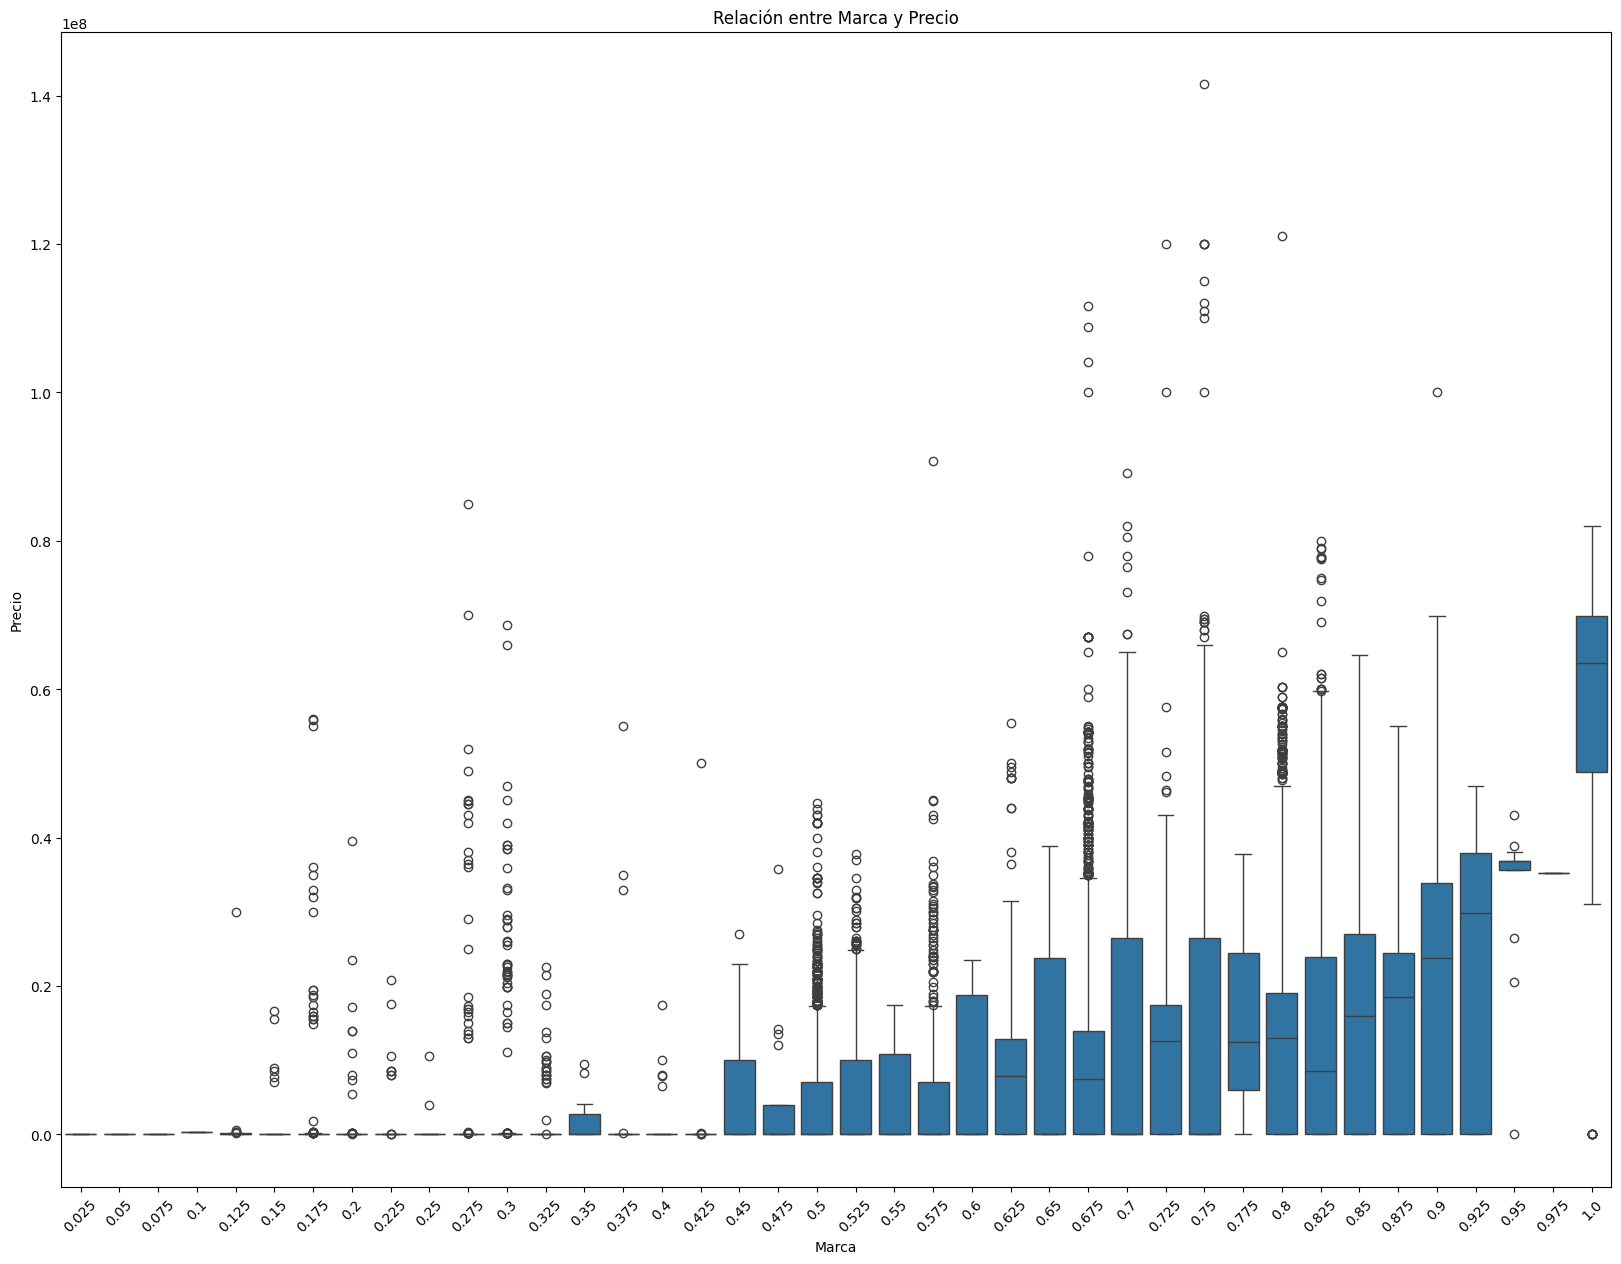

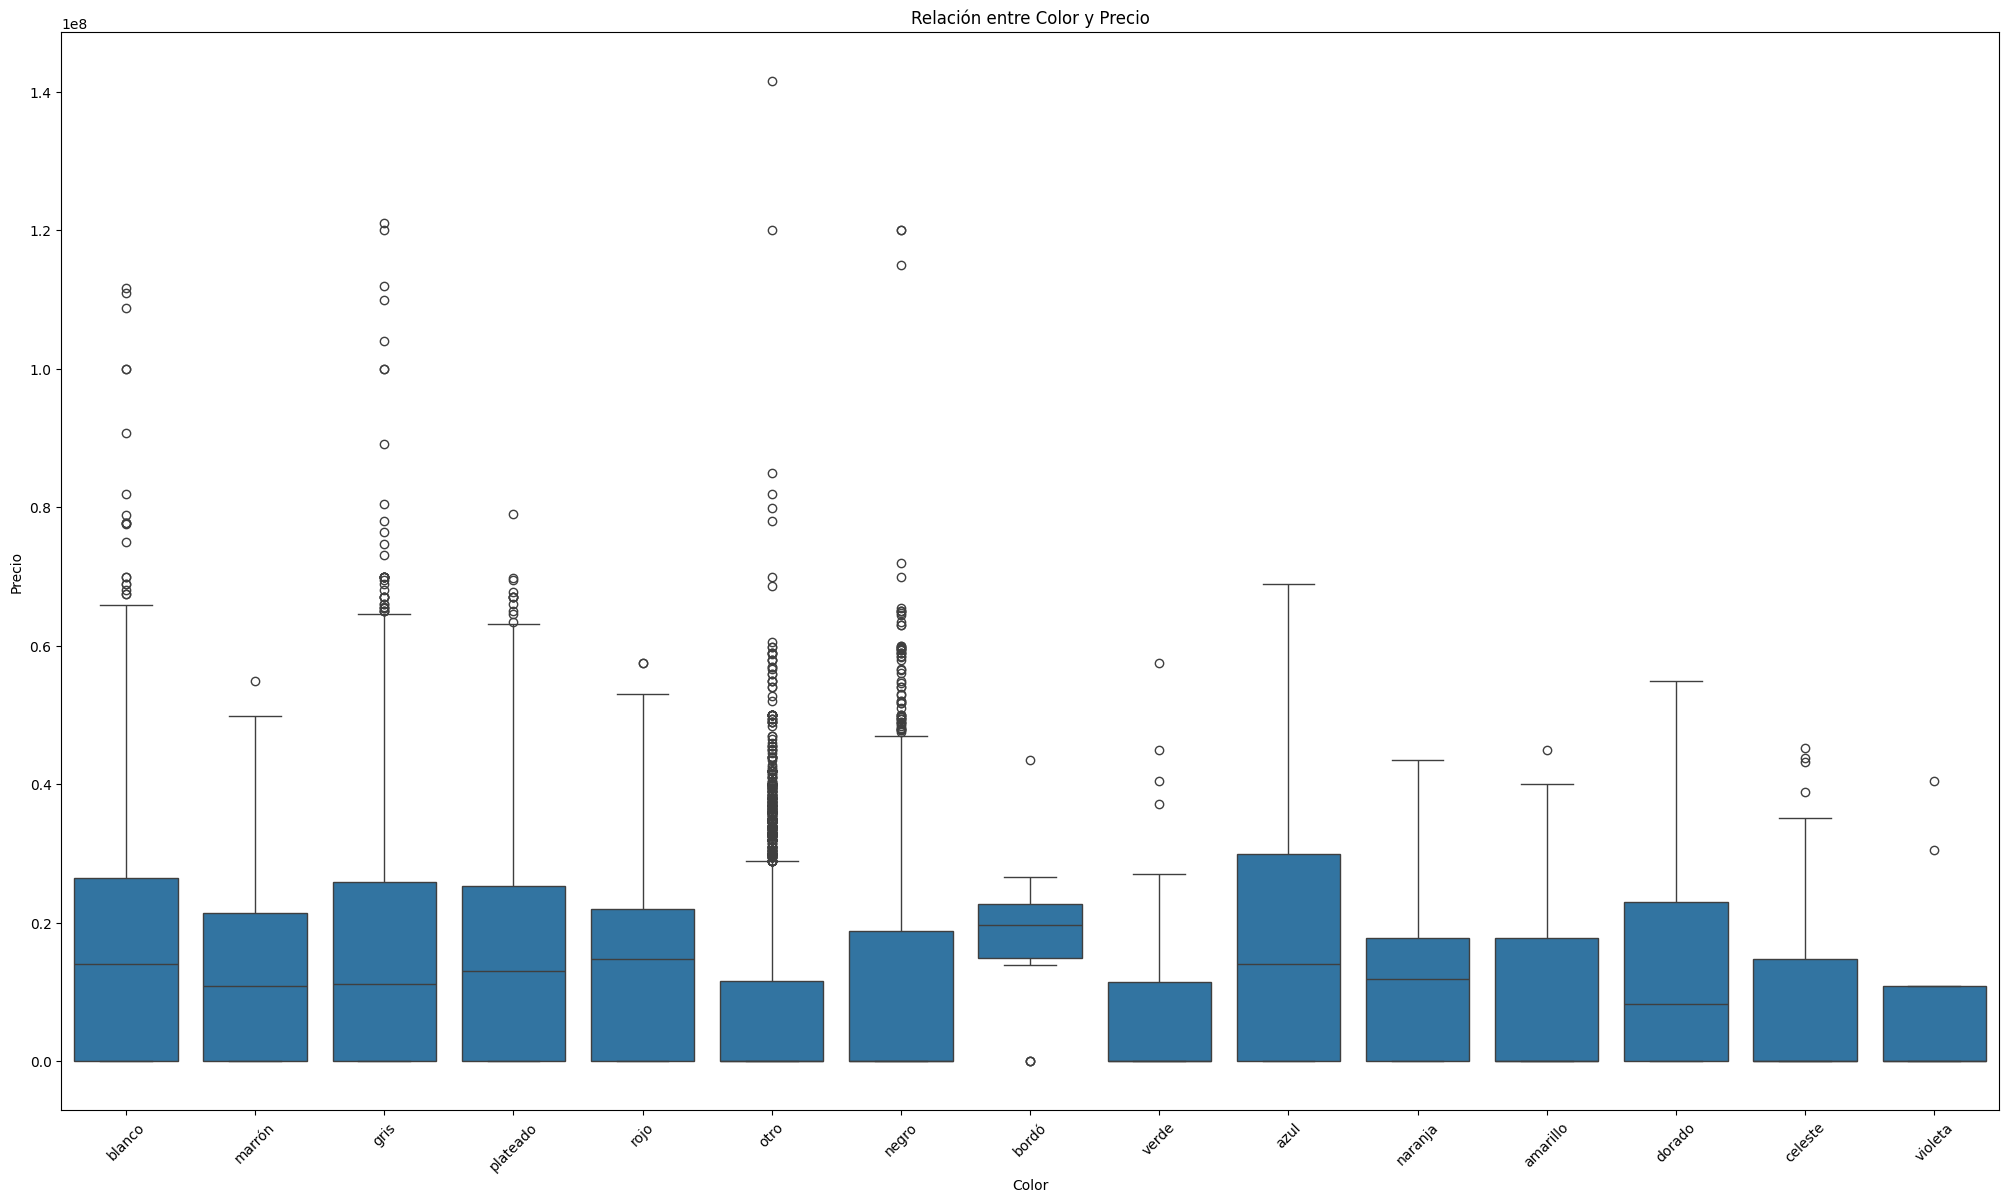

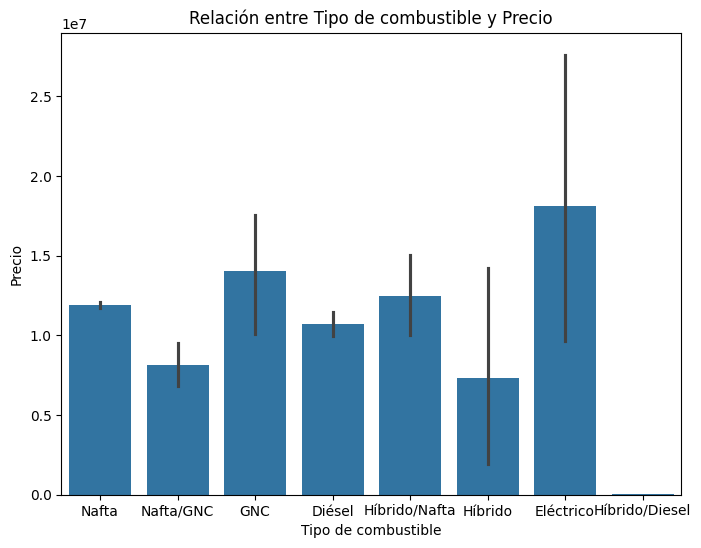

In [ ]:
# Box plot para Marca vs Precio
plt.figure(figsize=(20, 15))
sns.boxplot(x='Marca', y='Precio', data=df)
plt.xticks(rotation=45)
plt.title('Relación entre Marca y Precio')
plt.show()

# Box plot para Color vs Precio
plt.figure(figsize=(25, 14))
sns.boxplot(x='Color', y='Precio', data=df)
plt.xticks(rotation=45)
plt.title('Relación entre Color y Precio')
plt.show()

# Bar plot para Tipo de combustible vs Precio
plt.figure(figsize=(8, 6))
sns.barplot(x='Tipo de combustible', y='Precio', data=df)
plt.title('Relación entre Tipo de combustible y Precio')
plt.show()


In [ ]:
def transform_features_color(features, a):
    if a == True:

        list_color = {"gris": ["gris", "gray"], "blanco": ["blanco", "blanca"], "negro": ["negro", "negra", "black"],
                  "plateado": ["plateado", "plata"], "azul": ["azul", "blue"], "rojo": ["rojo", "red"],
                  "marrón": ["marrón", "café"], "dorado": ["dorado"], "verde": ["verde"], "celeste": ["celeste"],
                  "naranja": ["naranja", "orange"], "amarillo": ["amarillo"], "violeta": ["violeta"],
                  "bordó": ["bordó"]}
        dic_count = {key: 0 for key in list_color}
        dic_count["otro"] = 0

        for index, value in features["Color"].items():
            if isinstance(value, str):
                word = value.lower()
                cond = False
                for key, sub_list_color in list_color.items():
                    for color in sub_list_color:
                        if color in word:
                            features.loc[index, "Color"] = key
                            dic_count[key] += 1
                            cond = True
                            break
                    if cond:
                        break
                if cond == False:
                    features.loc[index, "Color"] = "otro"
                    dic_count["otro"] += 1
            else:
                features.loc[index, "Color"] = "otro"
                dic_count["otro"] += 1
                        
        return features

In [ ]:

df = transform_features_color(df,True)
print()
precio_promedio_por_marca = df.groupby('Tipo de combustible')['Precio'].mean().reset_index()
print(precio_promedio_por_marca)
# Ordenar las marcas por precio promedio de manera descendente
marcas_ordenadas = precio_promedio_por_marca.sort_values(by='Precio', ascending=False)['Tipo de combustible'].tolist()
print(marcas_ordenadas)


  Tipo de combustible        Precio
0              Diésel  1.070556e+07
1           Eléctrico  1.811816e+07
2                 GNC  1.401345e+07
3             Híbrido  7.295506e+06
4      Híbrido/Diesel  1.500000e+04
5       Híbrido/Nafta  1.246818e+07
6               Nafta  1.190988e+07
7           Nafta/GNC  8.150358e+06
['Eléctrico', 'GNC', 'Híbrido/Nafta', 'Nafta', 'Diésel', 'Nafta/GNC', 'Híbrido', 'Híbrido/Diesel']


In [ ]:
list_max_to_min_price = ['Eléctrico', 'GNC', 'Híbrido/Nafta', 'Nafta', 'Diésel', 'Nafta/GNC', 'Híbrido', 'Híbrido/Diesel']

size_list = len(list_max_to_min_price) 
order_list = {cat: (size_list - i) / size_list
                  for i, cat in enumerate(list_max_to_min_price)}


def map_feature_to_valor(cat):
    return order_list.get(cat, 0)

df['Tipo de combustible'] = df['Tipo de combustible'].map(map_feature_to_valor)

In [ ]:

print(df["Tipo de combustible"].values)
elemento = df['Tipo de combustible'].iloc[773]
print(elemento)

[0.625 0.625 0.625 ... 0.625 0.625 0.625]
0.625


In [ ]:

precio_promedio_por_marca = df.groupby('Transmisión')['Precio'].mean().reset_index()
print(precio_promedio_por_marca)
# Ordenar las marcas por precio promedio de manera descendente
marcas_ordenadas = precio_promedio_por_marca.sort_values(by='Precio', ascending=False)['Transmisión'].tolist()
print(marcas_ordenadas)

             Transmisión        Precio
0             Automática  1.336435e+07
1  Automática secuencial  2.260607e+07
2                 Manual  8.562566e+06
3         Semiautomática  2.275562e+07
['Semiautomática', 'Automática secuencial', 'Automática', 'Manual']


In [ ]:

precio_promedio_por_marca = df.groupby('Puertas')['Precio'].mean().reset_index()
print(precio_promedio_por_marca)
# Ordenar las marcas por precio promedio de manera descendente
marcas_ordenadas = precio_promedio_por_marca.sort_values(by='Precio', ascending=False)['Puertas'].tolist()
print(marcas_ordenadas)

   Puertas        Precio
0      2.0  2.099836e+06
1      3.0  1.743648e+06
2      4.0  1.332864e+07
3      5.0  1.178825e+07
4      6.0  4.180638e+07
[6.0, 4.0, 5.0, 2.0, 3.0]


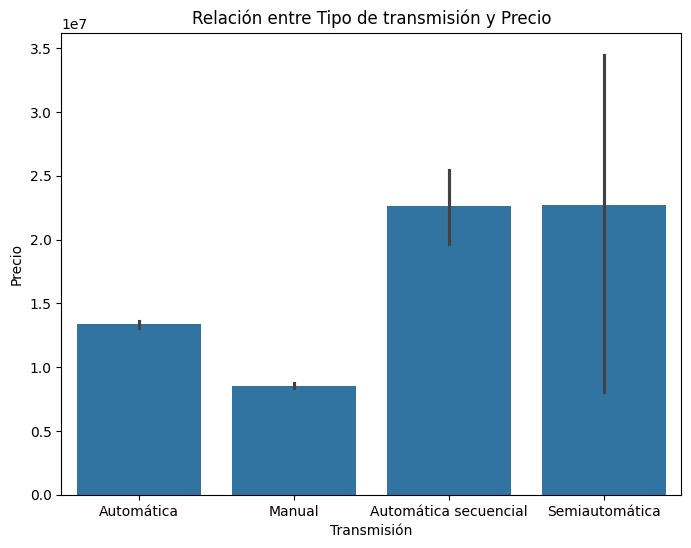

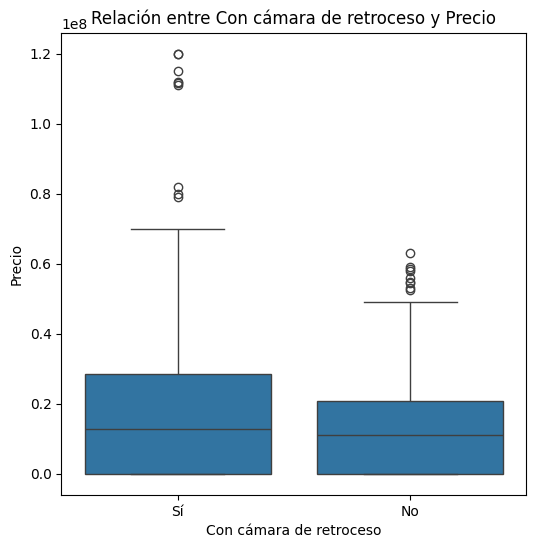

In [ ]:
# Bar plot para Tipo de transmisión vs Precio
plt.figure(figsize=(8, 6))
sns.barplot(x='Transmisión', y='Precio', data=df)
plt.title('Relación entre Tipo de transmisión y Precio')
plt.show()

# Box plot para Con cámara de retroceso vs Precio
plt.figure(figsize=(6, 6))
sns.boxplot(x='Con cámara de retroceso', y='Precio', data=df)
plt.title('Relación entre Con cámara de retroceso y Precio')
plt.show()
